In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import imghdr
from sklearn.model_selection import train_test_split

C:\Users\Athira K Dinesan\AppData\Local\Temp\ipykernel_15768\3860399619.py:7: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [2]:
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val   = np.load('X_val.npy')
y_val   = np.load('y_val.npy')
X_test  = np.load('X_test.npy')
y_test  = np.load('y_test.npy')

In [3]:
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [4]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

d:\Project\DDD_github\Driver-Drowsiness-Detection-\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1698/1698 ━━━━━━━━━━━━━━━━━━━━ 170s 87ms/step - accuracy: 0.9354 - loss: 0.1752 - val_accuracy: 0.9713 - val_loss: 0.0823
Epoch 2/10
1698/1698 ━━━━━━━━━━━━━━━━━━━━ 126s 74ms/step - accuracy: 0.9732 - loss: 0.0771 - val_accuracy: 0.9799 - val_loss: 0.0598
Epoch 3/10
1698/1698 ━━━━━━━━━━━━━━━━━━━━ 119s 70ms/step - accuracy: 0.9788 - loss: 0.0603 - val_accuracy: 0.9813 - val_loss: 0.0530
Epoch 4/10
1698/1698 ━━━━━━━━━━━━━━━━━━━━ 117s 69ms/step - accuracy: 0.9822 - loss: 0.0504 - val_accuracy: 0.9858 - val_loss: 0.0420
Epoch 5/10
1698/1698 ━━━━━━━━━━━━━━━━━━━━ 112s 66ms/step - accuracy: 0.9838 - loss: 0.0472 - val_accuracy: 0.9856 - val_loss: 0.0404
Epoch 6/10
1698/1698 ━━━━━━━━━━━━━━━━━━━━ 106s 62ms/step - accuracy: 0.9852 - loss: 0.0420 - val_accuracy: 0.9858 - val_loss: 0.0403
Epoch 7/10
1698/1698 ━━━━━━━━━━━━━━━━━━━━ 108s 64ms/step - accuracy: 0.9864 - loss: 0.0373 - val_accuracy: 0.9868 - val_loss: 0.0412
Epoch 8/10
1698/1698 ━━━━━━━━━━━━━━━━━━━━ 123s 72ms/step - accuracy: 

In [9]:
model.save("eye_state_cnn_20_20.keras")

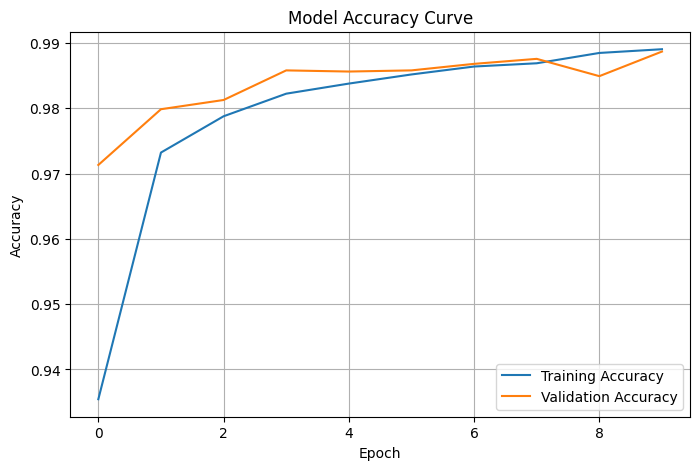

In [7]:
import matplotlib.pyplot as plt

# history is returned from model.fit()
# Example: history = model.fit(...)

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

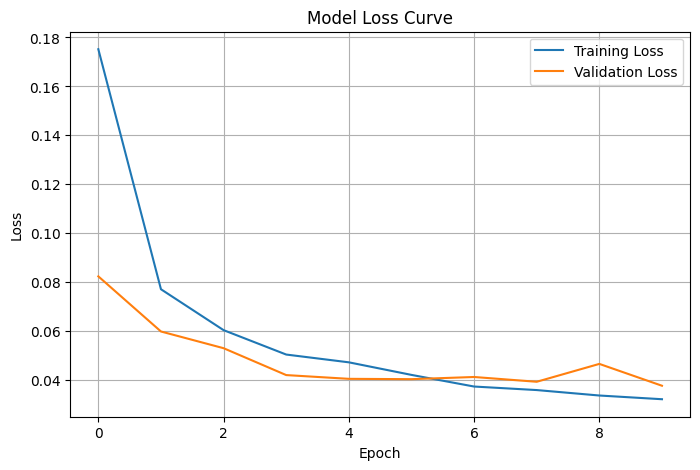

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()